In [ ]:
source("../utils.R")
data <- LoadH5Seurat("./obj_all.h5seurat")
deg_mait_rna <- readRDS("./deg_mait_rna.rds")
# DimPlot ----
data$cell_type_tb3 <- data$third_party_l
data$cell_type_tb3[data$group_ != 'tb'] <- 'background'
data$cell_type_tb3[data$cell_type_tb3 == 'NA'] <- 'background'

label_sorted <- sort(unique(data$cell_type_tb3),decreasing = T)

color <- c("#E1E1E1", "#8985dc", "#d193a5", "#7af5e0", "#43d1d2", "#789f57", 
           "#fb5258", "#338bac", "#fcef84", "#71a8b8", "#445838", "#544ece", 
           "#c93fd6", "#6f81c9", "#548f63", "#6aa8f6", "#7ea39b", "#6454b0", 
           "#fbce8b", "#d438f2", "#f64b9a", "#a07356", "#f8f6d8", "#dfc04c", 
           "#b0676d", "#94983a", "#5f7f4a", "#df58d1", "#af65e4", "#63d56a", 
           "#c0e255")

The legacy packages maptools, rgdal, and rgeos, underpinning the sp package,
which was just loaded, will retire in October 2023.
Please refer to R-spatial evolution reports for details, especially
https://r-spatial.org/r/2023/05/15/evolution4.html.
It may be desirable to make the sf package available;
package maintainers should consider adding sf to Suggests:.
The sp package is now running under evolution status 2
     (status 2 uses the sf package in place of rgdal)

Attaching SeuratObject

Registered S3 method overwritten by 'SeuratDisk':
  method            from  
  as.sparse.H5Group Seurat

Loading required package: ensembldb

Loading required package: BiocGenerics


Attaching package: 'BiocGenerics'


The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs


The following objects are masked from 'package:base':

    Filter, Find, Map, Position, Reduce, anyDuplicated, append,
    as.data.frame, basename, cbind, colnames, dirname, do.call,
    duplicated

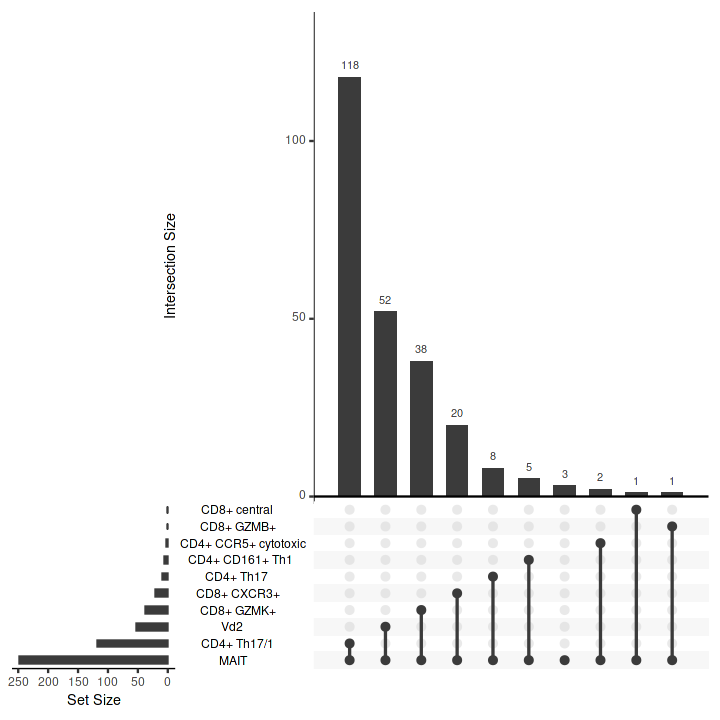

In [ ]:
library(UpSetR)
options(repr.plot.width = 6, repr.plot.height = 6)
input <- c(`MAIT`=3,
           `CD8+ central&MAIT`=1,
           `CD8+ GZMB+&MAIT`=1,
           `CD4+ CCR5+ cytotoxic&MAIT`=2,
           `CD4+ CD161+ Th1&MAIT`=5,
           `CD4+ Th17&MAIT`=8,
           `CD8+ CXCR3+&MAIT`=20,
           `CD8+ GZMK+&MAIT`=38,
           `Vd2&MAIT`=52,
           `CD4+ Th17/1&MAIT`=118)
p1 <- upset(fromExpression(input), order.by = "freq",nsets = 20)
p1

In [ ]:
celltype_marker <- list(
  B = c('CD79A'),
  Plasmablast = c('MZB1'),
  CD4 = c('CD3D','CD4'),
  CD8 = c('CD8A','GNLY','GZMK','GZMB','TRGV9'),
  Treg=c("IKZF2"),
  Naive = c("IL7R","CCR7","SELL","TCF7"),
  NK = c('NKG7','NCAM1'),
  MAIT = c('SLC4A10'),
  Monocyte = c('CD14','FCGR3A','S100A9'),
  cDC=c("HLA-DQA1","HLA-DQB1"),
  pDC = c('IRF7'),
  Platelets=c("PPBP"),
  RBC = c('HBB'),
  HSC=c("CD34")
)
p2 <- DotPlot(data,
        assay = 'rna',
        features = unique(c(list_c(celltype_marker),"SLC4A10")),
        group.by = "cell_type_tb2")+
  coord_flip()+
  theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1))

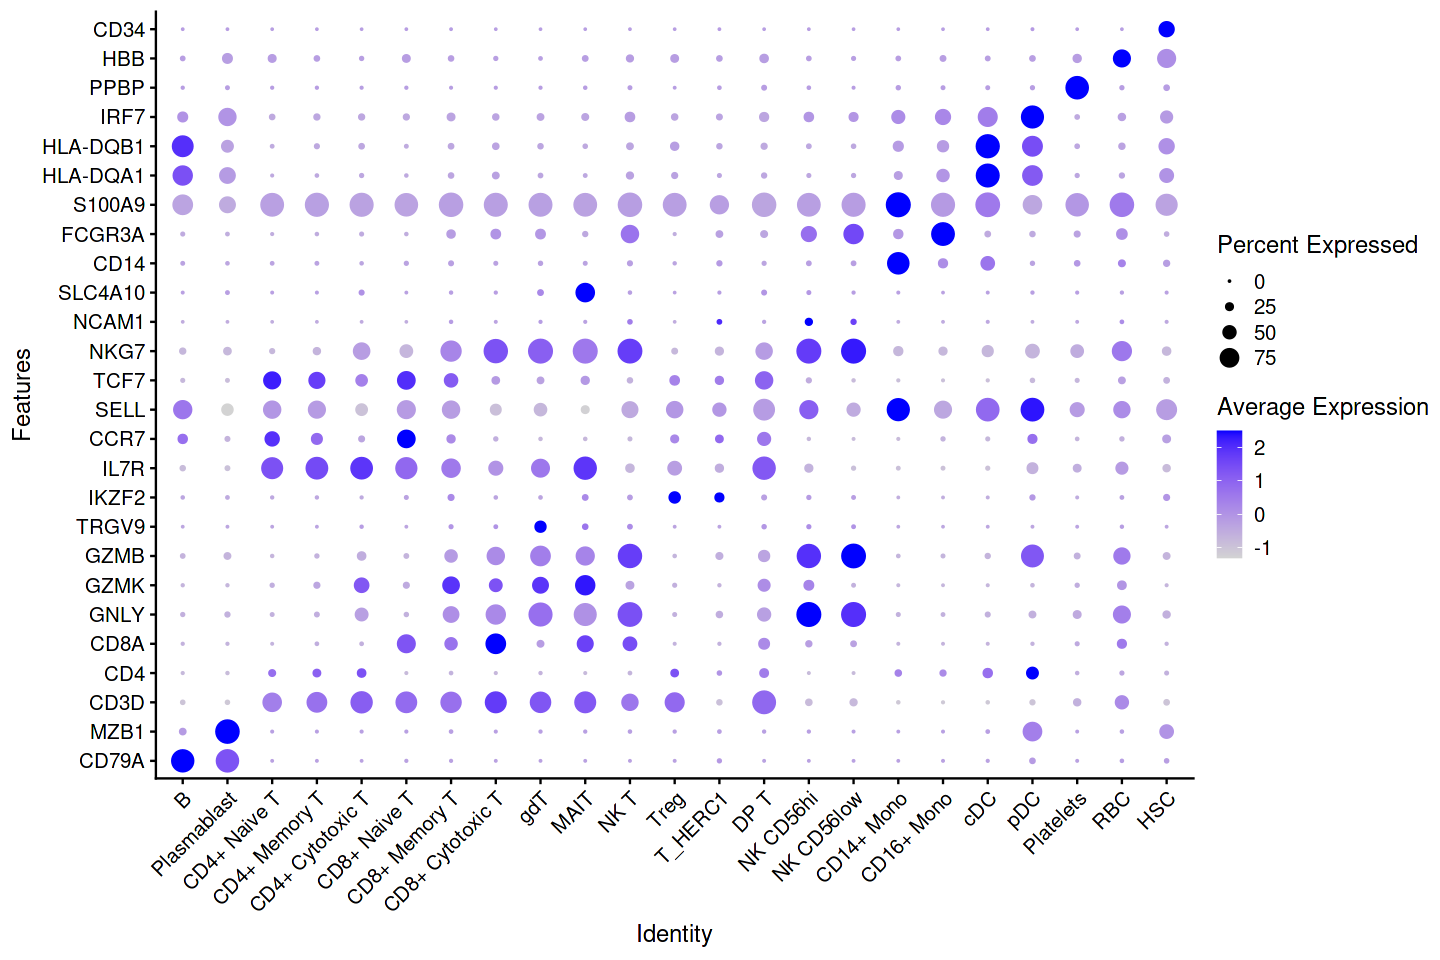

In [54]:
options(repr.plot.width = 12, repr.plot.height = 8)
p2

In [ ]:
p3 <-subset(data,cell_type_tb2 %in% c("CD4+ Naive T","CD4+ Memory T", "CD4+ Cytotoxic T",
                                 "CD8+ Naive T", "CD8+ Memory T", "CD8+ Cytotoxic T",
                                 "gdT", "MAIT","NK T", "Treg","T_HERC1","DP T")) |>
        VlnPlot(,
                sort = T,
                assay = 'adt',
                features = 'tcr.v.7.2',
                pt.size = 0,
                group.by = "cell_type_tb2",
                raster = F)

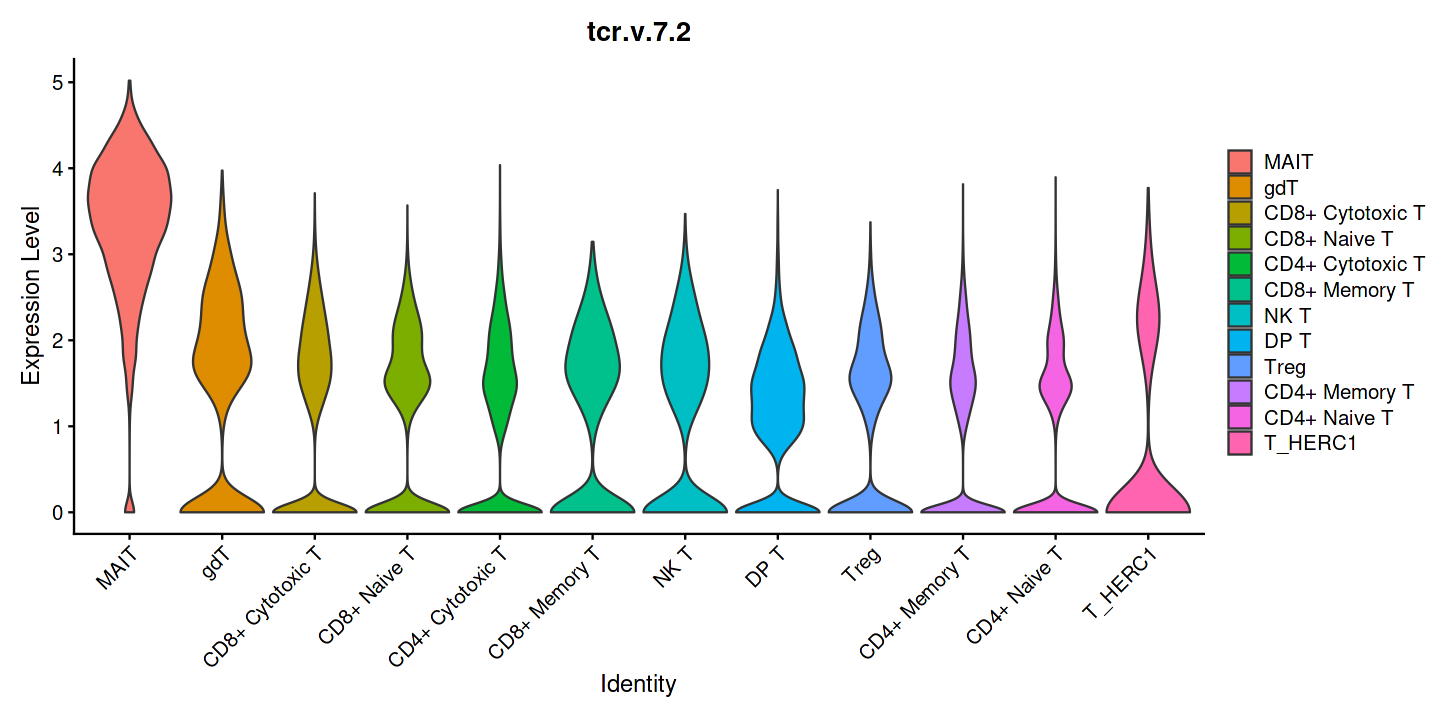

In [4]:
options(repr.plot.width = 12, repr.plot.height = 6)
p3

In [12]:
library(tidyr)
library(ggpubr)

cellIdent <- data.frame(orig.ident = data$orig.ident,
                        design = data$group_,
                        cluster = data$cell_type_tb2)

plot.data <- cellIdent |> 
  filter(cluster %in% c("CD4+ Memory T", "CD4+ Cytotoxic T",
                        "CD8+ Memory T", "CD8+ Cytotoxic T",
                        "gdT", "MAIT", "Treg","T_HERC1","DP T")) |>
  group_by(orig.ident,design,cluster) |> 
  summarise(count = n()) |> 
  group_by(orig.ident,design) |> 
  mutate(freq = round(count/(sum(count)),3)) |> 
  select(orig.ident,design,cluster,freq) |> 
  pivot_wider(names_from = cluster,values_from = freq,values_fill = 0)

plot.data = plot.data[,2:ncol(plot.data)]
plot.data = pivot_longer(plot.data,cols = 2:ncol(plot.data),
                         names_to = 'cluster',
                         values_to = 'Fraction')

p4 <- plot.data |> 
  filter(cluster == "MAIT") |> 
  ggboxplot(x='design',y='Fraction',
            color = 'design',
            add = 'jitter',
            palette = 'RdBu')+
  stat_compare_means(comparisons = list(c("health",'covid'),
                                        c("health",'iav'),
                                        c("health",'tb')),
                     method = "wilcox.test",
                     bracket.size = 0.3,
                     label = "p.signif",
                     hide.ns = F,
                     tip.length = 0.0,
                     step.increase = 0.1)+
  theme(axis.text.x  = element_text(size = 12),
        axis.text.y  = element_text(size = 12),
        # panel.border = element_rect(fill=NA,color="black",linetype="solid",size = 1),
        legend.position = 'none')

`summarise()` has grouped output by 'orig.ident', 'design'. You can override
using the `.groups` argument.


Warning message in wilcox.test.default(c(0.056, 0.081, 0.088, 0.032, 0.036, 0.033, :
"cannot compute exact p-value with ties"
Warning message in wilcox.test.default(c(0.056, 0.081, 0.088, 0.032, 0.036, 0.033, :
"cannot compute exact p-value with ties"
Warning message in wilcox.test.default(c(0.056, 0.081, 0.088, 0.032, 0.036, 0.033, :
"cannot compute exact p-value with ties"


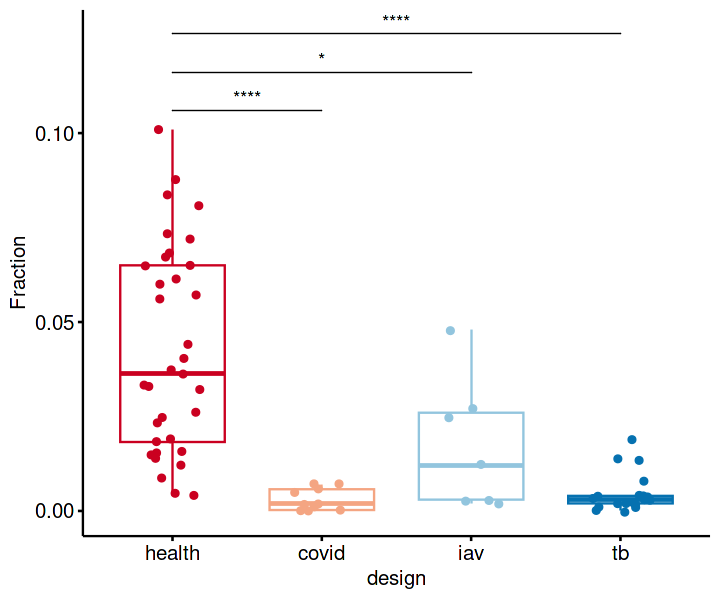

In [13]:
options(repr.plot.width = 6, repr.plot.height = 5)
p4